## Import dataframe

In [1]:
import pandas as pd

In [2]:
stays_df = pd.read_feather('stays.feather')

In [3]:
stays_df.Admission = pd.to_datetime(stays_df.Admission, format='ISO8601')
stays_df.Discharge = pd.to_datetime(stays_df.Discharge, format='ISO8601')
stays_df.ReAdmission = pd.to_datetime(stays_df.ReAdmission, format='ISO8601')
stays_df.ReAdmissionDischarge = pd.to_datetime(stays_df.ReAdmissionDischarge, format='ISO8601')
stays_df.FirstPosCollected = pd.to_datetime(stays_df.FirstPosCollected, format='ISO8601')

stays_df

,Age,Admission,Discharge,ReAdmission,ReAdmissionDischarge,FirstPosCollected,Acquisition
0,88,2021-12-01 07:22:04.672,2021-12-01 12:08:15.104,2021-12-13 13:37:28.576,2021-12-13 16:45:20.768,2021-12-01 07:35:11.104,Community-Onset Community-Associated
3,48,2021-12-01 12:47:34.400,2021-12-07 19:29:21.408,2021-12-13 16:34:25.408,2021-12-19 09:26:05.056,2021-12-01 16:50:03.392,Community-Onset Community-Associated
4,39,2021-12-01 16:34:45.888,2021-12-04 18:59:57.056,NaT,NaT,2021-12-01 17:42:29.120,Community-Onset Community-Associated
5,72,2021-12-01 20:00:06.656,2021-12-23 14:39:05.216,NaT,NaT,2021-12-01 21:23:07.392,Community-Onset Community-Associated
6,73,2021-12-01 13:40:00.128,2021-12-02 20:04:05.248,NaT,NaT,2021-12-02 06:37:59.680,Community-Onset Community-Associated
...,...,...,...,...,...,...,...
5615,75,2024-05-31 11:29:12.192,2024-06-02 16:34:15.168,NaT,NaT,2024-05-31 17:20:54.784,Community-Onset Community-Associated
5616,56,2024-03-17 23:35:30.560,NaT,NaT,NaT,2024-06-01 02:37:58.144,Hospital-Onset Healthcare-Associated
5617,80,2024-06-03 11:10:32.960,2024-06-13 18:34:27.200,NaT,NaT,2024-06-03 11:38:56.896,Community-Onset Community-Associated
5618,88,2024-06-03 17:39:23.776,2024-06-12 11:59:26.720,NaT,NaT,2024-06-03 17:52:30.208,Community-Onset Community-Associated


## Filtering by Age

In [4]:
from itertools import pairwise
import re


def age_groups(age_breakpoints: str):
    # Validate str input
    age_breakpoints = '' if not age_breakpoints else age_breakpoints  # Handle None

    regex = r'^\d+(,\d+)*$'

    assert re.fullmatch(regex, age_breakpoints) is not None, \
        'Invalid input.  Expected a string of integers delimited by commas.'

    # Empty string case: single age group
    if age_breakpoints == '':
        return [{
            'lower': 0,
            'upper': None,
            'query': "Age >= 0"
        }]

    # Split str by comma and generate a dict for each age group
    age_breakpoints = age_breakpoints.split(',')
    age_breakpoints = [int(age) for age in age_breakpoints]

    assert all(x < y for x, y in pairwise(age_breakpoints)), \
        'Age breakpoints must be in strictly ascending order with no duplicates.'

    pairs = list(pairwise([0] + age_breakpoints + [None]))
    return [
        {
            'lower': pair[0],
            'upper': pair[1],
            'query': f"Age >= {pair[0]}{f' and Age < {pair[1]}' if pair[1] is not None else ''}"
        }
        for pair in pairs
    ]

### Test age_groups function

In [5]:
def test_age_groups(s: str):
    try:
        return age_groups(s)
    except AssertionError as e:
        return str(e)

In [6]:
display(test_age_groups('16,65'))
display(test_age_groups('16, 65'))
display(test_age_groups('16.65'))

[{'lower': 0, 'upper': 16, 'query': 'Age >= 0 and Age < 16'},
 {'lower': 16, 'upper': 65, 'query': 'Age >= 16 and Age < 65'},
 {'lower': 65, 'upper': None, 'query': 'Age >= 65'}]

'Invalid input.  Expected a string of integers delimited by commas.'

'Invalid input.  Expected a string of integers delimited by commas.'

In [7]:
display(test_age_groups('65,16'))
display(test_age_groups('16,16'))

'Age breakpoints must be in strictly ascending order with no duplicates.'

'Age breakpoints must be in strictly ascending order with no duplicates.'

In [8]:
display(test_age_groups('65'))
display(test_age_groups(''))

[{'lower': 0, 'upper': 65, 'query': 'Age >= 0 and Age < 65'},
 {'lower': 65, 'upper': None, 'query': 'Age >= 65'}]

'Invalid input.  Expected a string of integers delimited by commas.'

In [9]:
display(test_age_groups('0,,16'))

'Invalid input.  Expected a string of integers delimited by commas.'

## Data cleaning and date filtering

In [10]:
df = stays_df.copy()
df = df.assign(Start = df.Admission)
df.loc[df.Acquisition.str.startswith('Hospital'), 'Start'] = df.FirstPosCollected
start = pd.Timestamp('2022-05-18')
end = pd.Timestamp('2022-09-03')
df = df.query('Start >= @start and Start < @end')
df = df.loc[df.Discharge.notna()]
df

,Age,Admission,Discharge,ReAdmission,ReAdmissionDischarge,FirstPosCollected,Acquisition,Start
1612,0,2022-05-18 00:04:45.696,2022-05-19 14:55:39.520,NaT,NaT,2022-05-18 03:51:57.184,Community-Onset Community-Associated,2022-05-18 00:04:45.696
1614,64,2022-05-18 23:11:56.416,2022-06-13 19:29:50.080,NaT,NaT,2022-05-19 00:54:36.800,Community-Onset Suspected Healthcare-Associated,2022-05-18 23:11:56.416
1615,63,2022-05-19 11:23:45.536,2022-05-21 15:42:56.000,NaT,NaT,2022-05-19 12:29:17.696,Community-Onset Community-Associated,2022-05-19 11:23:45.536
1616,67,2022-04-17 12:48:24.576,2022-06-11 16:00:54.272,NaT,NaT,2022-05-19 15:30:36.672,Hospital-Onset Healthcare-Associated,2022-05-19 15:30:36.672
1618,85,2022-05-02 17:28:41.728,2022-05-21 14:33:01.696,NaT,NaT,2022-05-20 11:10:15.552,Hospital-Onset Healthcare-Associated,2022-05-20 11:10:15.552
...,...,...,...,...,...,...,...,...
2412,85,2022-09-01 00:59:16.352,2022-09-08 18:42:34.624,NaT,NaT,2022-09-01 04:13:41.760,Community-Onset Community-Associated,2022-09-01 00:59:16.352
2413,72,2022-08-17 23:48:18.560,2022-09-22 15:44:30.208,NaT,NaT,2022-09-01 11:10:56.512,Hospital-Onset Healthcare-Associated,2022-09-01 11:10:56.512
2414,77,2022-08-23 17:34:35.008,2022-09-09 18:00:40.704,NaT,NaT,2022-09-01 16:34:15.168,Hospital-Onset Suspected Healthcare-Associated,2022-09-01 16:34:15.168
2415,74,2022-08-02 18:11:13.536,2022-09-10 21:05:58.272,NaT,NaT,2022-09-01 19:22:27.712,Hospital-Onset Healthcare-Associated,2022-09-01 19:22:27.712


## LoS fitting

In [11]:
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import zscore
import os
import shutup

os.environ['LOGURU_AUTOINIT'] = '0'

import fitter
from base64 import b64encode, b64decode
from io import BytesIO
from IPython.display import Image

import json
import textwrap

In [12]:
g = age_groups('16,65')
query = g[2]['query']
query

'Age >= 65'

In [13]:
df = df.query(query)
df = df.assign(LoS = (df.Discharge - df.Admission) / pd.Timedelta(days=1))
df = df.assign(ReLoS = (df.ReAdmissionDischarge - df.ReAdmission) / pd.Timedelta(days=1))
df.ReLoS = df.ReLoS.fillna(0)
df = df.assign(TotalLoS = df.LoS + df.ReLoS)
los = df.TotalLoS.to_numpy()
print(len(los))

507


In [14]:
filtered_los = los[abs(zscore(los)) <= 3]
f= fitter.Fitter(filtered_los, distributions=fitter.get_common_distributions())
with shutup.mute_warnings:
    f.fit()

fit_df = f.df_errors.loc[
    np.isfinite(f.df_errors.sumsquare_error),
    ['sumsquare_error', 'aic', 'bic', 'ks_pvalue']
].sort_values(
    'sumsquare_error'
).assign(
    dist_mean = np.nan,
    dist_std = np.nan,
    data_mean = filtered_los.mean(),
    data_std = filtered_los.std()
)

with shutup.mute_warnings:
    for dist_name in fit_df.index:
        dist = getattr(stats, dist_name)(*f.fitted_param[dist_name])
        fit_df.loc[dist_name, 'dist_mean'] = dist.mean()
        fit_df.loc[dist_name, 'dist_std'] = dist.std()

fit_df = fit_df.loc[fit_df.dist_mean.notna() & fit_df.dist_std.notna()]
fit_df = fit_df.assign(
    mean_ratio = fit_df.dist_mean / fit_df.data_mean,
    std_ratio = fit_df.dist_std / fit_df.data_std,
)

# Use the default scoring system for best fit (sum of squared errors)
# but remove distributions whose means and standard deviations deviate too much from
# the empirical values.
fit_df = fit_df.query('0.95 < mean_ratio < 1.05 and 0.9 < std_ratio < 1.1')\
    .sort_values(by='sumsquare_error')

assert len(fit_df > 1), 'Could not get a good fit to the LoS data.'

best_dist_type = fit_df.index[0]
best_dist_type

'gamma'

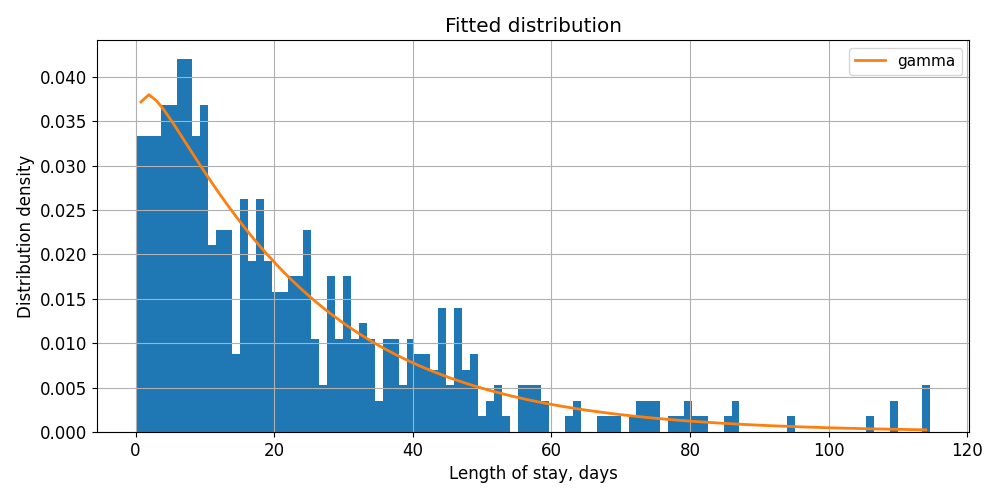

In [15]:
f2 = fitter.Fitter(filtered_los, distributions=[best_dist_type])
f2.fit()

plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(10,5))
f2.hist()
f2.plot_pdf()
plt.legend(fontsize='11', loc='upper right')
plt.title(f'Fitted distribution')
plt.xlabel('Length of stay, days')
plt.ylabel('Distribution density')

io = BytesIO()
plt.tight_layout(pad=1)
plt.savefig(io, format='png')
io.seek(0)
png_encoded = b64encode(io.read())

plt.close()  # Do not show figure, we will load the generated PNG in the next step

Image(b64decode(png_encoded))

In [16]:
def get_params(dist_name):

    # Inspired by the code for Fitter.get_best()
    d = getattr(stats, dist_name)
    return (d.shapes + ", loc, scale").split(", ") if d.shapes else ["loc", "scale"]

params = {n: dict(zip(get_params(n), v)) for n, v in f2.fitted_param.items()}

print(f'''\
Distribution type: {best_dist_type}
Distribution parameters:
{textwrap.indent(json.dumps(params[best_dist_type], indent=2), '  ')}
''')

Distribution type: gamma
Distribution parameters:
  {
    "a": 1.069561598886756,
    "loc": 0.19573766052857972,
    "scale": 21.134520615931415
  }

